In [35]:
import pandas as pd
import seaborn as sns


In [36]:

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']

pima = pd.read_csv("datasets/diabetes/diabetes.csv",header=0,names=col_names)


# pima = pima.apply(pd.to_numeric)
pima.dtypes

pregnant      int64
glucose       int64
bp            int64
skin          int64
insulin       int64
bmi         float64
pedigree    float64
age           int64
label         int64
dtype: object

In [37]:
# Selecting the features and target variable
#split dataset in features and target variable
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
# X = pima.iloc[:, :-1] # Features
# y = pima.iloc[:, -1] # Target variable
X=pima[feature_cols] # Features
y=pima.label # Target variable


In [38]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

In [44]:
print('Train set:', X_train, y_train)
print('Test set:', X_test, y_test)

Train set:      pregnant  insulin   bmi  age  glucose  bp  pedigree
695         7      480  30.4   43      142  90     0.128
119         4       51  23.2   21       99  76     0.223
135         2      140  33.8   31      125  60     0.088
675         6        0  30.9   31      195  70     0.328
326         1      156  35.1   30      122  64     0.692
..        ...      ...   ...  ...      ...  ..       ...
321         3        0  31.6   25      112  74     0.197
581         6        0  25.0   27      109  60     0.206
121         6        0  34.2   24      111  64     0.260
238         9        0  30.8   32      164  84     0.831
681         0        0  49.6   26      162  76     0.364

[576 rows x 7 columns] 695    1
119    0
135    0
675    1
326    1
      ..
321    1
581    0
121    0
238    1
681    1
Name: label, Length: 576, dtype: int64
Test set:      pregnant  insulin   bmi  age  glucose  bp  pedigree
515         3      105  31.6   28      163  70     0.268
462         8      

In [39]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

d:\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[115,  10],
       [ 25,  42]])

In [46]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.82      0.92      0.87       125
   with diabetes       0.81      0.63      0.71        67

        accuracy                           0.82       192
       macro avg       0.81      0.77      0.79       192
    weighted avg       0.82      0.82      0.81       192



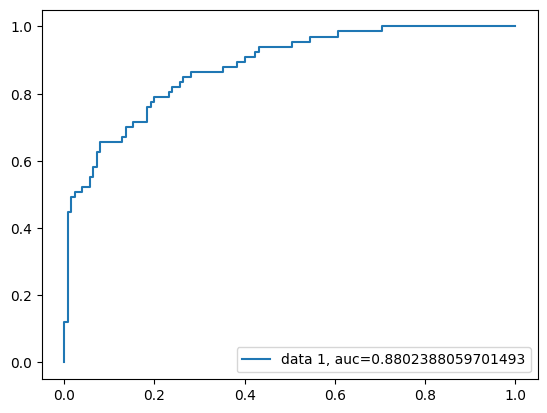

In [47]:
import matplotlib.pyplot as plt

y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()